# 🌿 Wetland Habitat Mapping with Machine Learning

## Collaborative Annotation Workflow for Biodiversity & Climate Adaptation

**ESA Contract No. 4000144740/24/I-DT-bgh** | JupyterGIS Demo

---

### Data Source: EOPF Sentinel Zarr Samples Service

This notebook uses the **ESA EOPF Sample Service** - the new cloud-native Zarr format for Copernicus Sentinel data.

- 🌐 Data endpoint: `https://objects.eodc.eu`
- 📦 Format: EOPF Zarr (cloud-optimized, chunked arrays)
- 🛰️ Data: Sentinel-2 L2A (Tile T31UFS - Belgium/Netherlands)

### Use Case: Biodiversity Monitoring

Wetlands are critical ecosystems for:
- **Biodiversity**: Habitat for 40% of the world's species
- **Carbon storage**: Peatlands store 2x more carbon than all forests combined
- **Climate adaptation**: Natural flood mitigation and water purification

### ML Workflow

```
┌─────────────┐     ┌──────────────┐     ┌─────────────────┐     ┌──────────────┐     ┌─────────────┐
│ 1. Load     │ --> │ 2. Train     │ --> │ 3. Predict &    │ --> │ 4. Annotate  │ --> │ 5. Retrain  │
│    EOPF     │     │    Model v1  │     │    Visualize    │     │    Errors    │     │    Model v2 │
└─────────────┘     └──────────────┘     └─────────────────┘     └──────────────┘     └─────────────┘
```

## 📦 Setup & Imports

In [1]:
# Install required packages (run once)
!pip install s3fs xarray zarr rioxarray scikit-learn rasterio matplotlib jupytergis pyproj --quiet

In [2]:
# Core libraries
import os
import json
import warnings
from datetime import datetime
warnings.filterwarnings('ignore')

# Data handling
import numpy as np
import pandas as pd
import xarray as xr
import s3fs

# Geospatial
import rasterio
from rasterio.transform import from_bounds
from pyproj import Transformer

# Machine Learning
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
import joblib

# Visualization
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap

# JupyterGIS
try:
    from jupytergis import GISDocument
    JUPYTERGIS_AVAILABLE = True
except ImportError:
    JUPYTERGIS_AVAILABLE = False
    print("⚠️ JupyterGIS not available - will skip map creation")

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


## 🗺️ Study Area Configuration

We use the **EOPF Sample Data** available for tile **T31UFS** (Belgium/Netherlands border region).

This area contains wetlands along the Meuse River and in the Flemish lowlands.

In [3]:
# EOPF Sample Service configuration
EOPF_CONFIG = {
    "bucket": "e05ab01a9d56408d82ac32d69a5aae2a:sample-data",
    "prefix": "tutorial_data/cpm_v253/",
    "endpoint_url": "https://objects.eodc.eu",
    "tile": "T31UFS"  # Belgium/Netherlands
}

# Study area - subset of tile T31UFS
STUDY_AREA = {
    "name": "Meuse River Wetlands (Belgium/Netherlands)",
    "spatial_extent": {
        "west": 5.0,
        "south": 51.2,
        "east": 5.1,
        "north": 51.3
    },
    "target_crs": 32631  # UTM Zone 31N
}

# Wetland classes for classification
WETLAND_CLASSES = {
    0: {"name": "Other/Upland", "color": "#d9d9d9"},
    1: {"name": "Open Water", "color": "#0077be"},
    2: {"name": "Emergent Vegetation", "color": "#7fc97f"},
    3: {"name": "Wet Meadow", "color": "#a6d854"},
    4: {"name": "Flooded Forest", "color": "#beaed4"},
    5: {"name": "Bare/Mudflat", "color": "#fdc086"}
}

print(f"📍 Study Area: {STUDY_AREA['name']}")
print(f"📐 Bounding Box: {list(STUDY_AREA['spatial_extent'].values())}")
print(f"🛰️ EOPF Tile: {EOPF_CONFIG['tile']}")
print(f"\n🏷️ Wetland Classes:")
for k, v in WETLAND_CLASSES.items():
    print(f"   {k}: {v['name']}")

📍 Study Area: Meuse River Wetlands (Belgium/Netherlands)
📐 Bounding Box: [5.0, 51.2, 5.1, 51.3]
🛰️ EOPF Tile: T31UFS

🏷️ Wetland Classes:
   0: Other/Upland
   1: Open Water
   2: Emergent Vegetation
   3: Wet Meadow
   4: Flooded Forest
   5: Bare/Mudflat


## 📡 Step 1: Connect to EOPF Sample Service

Access Sentinel-2 data in EOPF Zarr format via S3-compatible storage.

In [4]:
# Create S3 filesystem connection
fs = s3fs.S3FileSystem(
    anon=True, 
    client_kwargs={"endpoint_url": EOPF_CONFIG["endpoint_url"]}
)

# Workaround for CEPH compatibility
try:
    handlers = fs.s3.meta.events._emitter._handlers
    handlers_to_unregister = handlers.prefix_search("before-parameter-build.s3")
    if handlers_to_unregister:
        handler_to_unregister = handlers_to_unregister[0]
        fs.s3.meta.events._emitter.unregister(
            "before-parameter-build.s3", handler_to_unregister
        )
except Exception as e:
    print(f"Note: Handler unregistration skipped: {e}")

# Find available Sentinel-2 L2A products
s3_pattern = f"s3://{EOPF_CONFIG['bucket']}/{EOPF_CONFIG['prefix']}S2*_MSIL2A_*_*_*_{EOPF_CONFIG['tile']}_*.zarr"
remote_files = fs.glob(s3_pattern)

# Convert to HTTP paths
paths = [f"{EOPF_CONFIG['endpoint_url']}/{f}" for f in remote_files]

print(f"🛰️ Found {len(paths)} Sentinel-2 L2A products for tile {EOPF_CONFIG['tile']}")
print("\n📅 Available dates:")
for p in paths[:5]:  # Show first 5
    filename = os.path.basename(p)
    date_str = filename.split("_")[2][:8]
    print(f"   {date_str[:4]}-{date_str[4:6]}-{date_str[6:8]}")
if len(paths) > 5:
    print(f"   ... and {len(paths) - 5} more")

🛰️ Found 12 Sentinel-2 L2A products for tile T31UFS

📅 Available dates:
   2021-02-11
   2021-02-24
   2021-04-25
   2021-06-01
   2021-06-14
   ... and 7 more


## 📥 Step 2: Load EOPF Zarr Data

Load Sentinel-2 bands and apply spatial subsetting to the study area.

In [5]:
# Get target CRS from first product
ds_meta = xr.open_datatree(paths[0], engine="zarr", chunks={}, decode_timedelta=False)
target_crs = ds_meta.attrs["stac_discovery"]["properties"]["proj:epsg"]
print(f"🌐 Target CRS: EPSG:{target_crs}")

# Transform spatial extent to UTM
transformer = Transformer.from_crs("EPSG:4326", f"EPSG:{target_crs}", always_xy=True)
west_utm, south_utm = transformer.transform(
    STUDY_AREA["spatial_extent"]["west"], 
    STUDY_AREA["spatial_extent"]["south"]
)
east_utm, north_utm = transformer.transform(
    STUDY_AREA["spatial_extent"]["east"], 
    STUDY_AREA["spatial_extent"]["north"]
)

x_slice = slice(west_utm, east_utm)
y_slice = slice(north_utm, south_utm)

print(f"📐 UTM bounds: X=[{west_utm:.0f}, {east_utm:.0f}], Y=[{south_utm:.0f}, {north_utm:.0f}]")

🌐 Target CRS: EPSG:32631
📐 UTM bounds: X=[639729, 646397], Y=[5673967, 5685281]


In [6]:
# Preprocessing function to extract time and crop
def extract_time_and_crop(ds):
    """Extract timestamp from filename and crop to study area."""
    date_format = "%Y%m%dT%H%M%S"
    filename = ds.encoding["source"]
    date_str = os.path.basename(filename).split("_")[2]
    time = datetime.strptime(date_str, date_format)
    ds = ds.assign_coords(time=time)
    return ds.sel(x=x_slice, y=y_slice)

# Load 10m bands (B02, B03, B04, B08)
print("📥 Loading 10m reflectance bands...")
r10m = xr.open_mfdataset(
    paths,
    engine="zarr",
    chunks={},
    group="/measurements/reflectance/r10m",
    concat_dim="time",
    combine="nested",
    preprocess=extract_time_and_crop,
    decode_cf=False,
    mask_and_scale=False,
)
r10m = r10m.sortby("time")

# Load SCL (Scene Classification Layer) for cloud masking
print("📥 Loading SCL for cloud masking...")
scl = xr.open_mfdataset(
    paths,
    engine="zarr",
    chunks={},
    group="conditions/mask/l2a_classification/r20m",
    concat_dim="time",
    combine="nested",
    preprocess=extract_time_and_crop,
    decode_cf=False,
    mask_and_scale=False,
)
scl = scl.sortby("time")

print(f"\n✅ Loaded data:")
print(f"   Dimensions: {dict(r10m.dims)}")
print(f"   Variables: {list(r10m.data_vars)}")
print(f"   Time range: {r10m.time.values[0]} to {r10m.time.values[-1]}")

📥 Loading 10m reflectance bands...
📥 Loading SCL for cloud masking...

✅ Loaded data:
   Dimensions: {'time': 12, 'y': 1131, 'x': 667}
   Variables: ['b02', 'b03', 'b04', 'b08']
   Time range: 2021-02-09T10:51:09.000000000 to 2021-09-07T10:46:19.000000000


In [7]:
# Apply cloud mask
def validate_scl(scl):
    """Create mask for valid (non-cloud) pixels."""
    # Invalid SCL classes: NO_DATA(0), SATURATED(1), CLOUD_SHADOW(3), 
    # CLOUD_MEDIUM(7), CLOUD_HIGH(8), THIN_CIRRUS(9), SNOW(10)
    invalid = [0, 1, 3, 7, 8, 9, 10]
    return ~scl.isin(invalid)

# Interpolate SCL to 10m resolution
print("🔧 Applying cloud mask...")
mask_scl_r10m = scl.scl.chunk(chunks={"x": -1, "y": -1}).interp(
    x=r10m["x"], y=r10m["y"], method="nearest"
)

valid_mask = validate_scl(mask_scl_r10m)
masked = r10m.where(valid_mask)

print("✅ Cloud mask applied!")

🔧 Applying cloud mask...
✅ Cloud mask applied!


In [8]:
# Select a single time step for classification (best cloud-free)
# Use median composite for more robust results
print("🔧 Creating cloud-free composite...")

# Compute median across time (simple compositing)
composite = masked.median(dim="time", skipna=True).compute()

print(f"✅ Composite created: {dict(composite.dims)}")

🔧 Creating cloud-free composite...
✅ Composite created: {'y': 1131, 'x': 667}


## 🧮 Step 3: Calculate Spectral Indices

In [9]:
import matplotlib.pyplot as plt

def get_scale_offset(ds, var_name):
    """Extract scale factor and offset from EOPF attributes."""
    try:
        attrs = ds[var_name].attrs.get("_eopf_attrs", {})
        scale = attrs.get("scale_factor", 0.0001)
        offset = attrs.get("add_offset", 0)
        return scale, offset
    except:
        return 0.0001, 0  # Default Sentinel-2 values

def calculate_indices(ds):
    """
    Calculate spectral indices for wetland mapping.
    
    Uses EOPF scale factors for proper reflectance conversion.
    """
    
    # Get scale factors (or use defaults)
    scale, offset = 0.0001, 0
    
    # Convert to reflectance
    blue = ds["b02"].values.astype(float) * scale + offset
    green = ds["b03"].values.astype(float) * scale + offset
    red = ds["b04"].values.astype(float) * scale + offset
    nir = ds["b08"].values.astype(float) * scale + offset
    
    # Calculate indices
    eps = 1e-10
    
    # NDVI - Vegetation health
    ndvi = (nir - red) / (nir + red + eps)
    
    # NDWI - Water detection (McFeeters)
    ndwi = (green - nir) / (green + nir + eps)
    
    # NDMI approximation using green as proxy for SWIR
    # (True NDMI needs B11 from 20m bands)
    ndmi_proxy = (nir - green) / (nir + green + eps)
    
    # Water Ratio Index
    wri = (green + red) / (nir + blue + eps)
    
    return {
        "blue": blue,
        "green": green,
        "red": red,
        "nir": nir,
        "ndvi": ndvi,
        "ndwi": ndwi,
        "ndmi_proxy": ndmi_proxy,
        "wri": wri
    }

# Calculate indices
indices = calculate_indices(composite)

print("✅ Calculated spectral indices:")
for name in ["ndvi", "ndwi", "ndmi_proxy", "wri"]:
    idx = indices[name]
    valid = ~np.isnan(idx)
    if valid.any():
        print(f"   {name.upper()}: min={np.nanmin(idx):.3f}, max={np.nanmax(idx):.3f}, mean={np.nanmean(idx):.3f}")

✅ Calculated spectral indices:
   NDVI: min=-0.063, max=0.691, mean=0.415
   NDWI: min=-0.626, max=0.129, mean=-0.398
   NDMI_PROXY: min=-0.129, max=0.626, mean=0.398
   WRI: min=0.351, max=1.178, mean=0.614


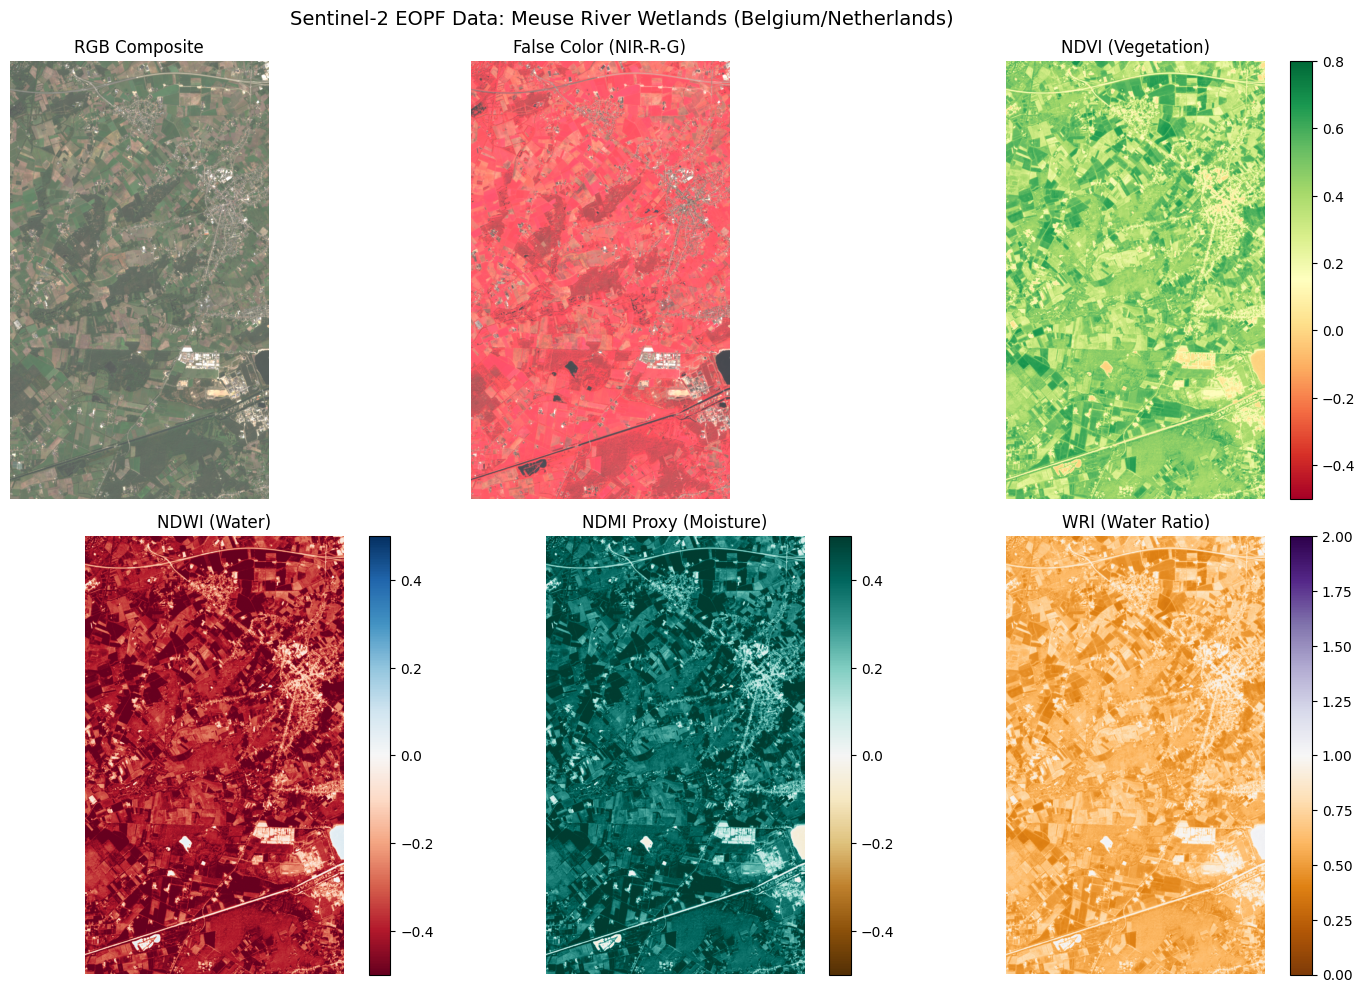

📊 Saved: wetland_indices.png


In [10]:
# Visualize data and indices
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# RGB composite
rgb = np.stack([indices["red"], indices["green"], indices["blue"]], axis=-1)
rgb = np.clip(rgb * 3, 0, 1)  # Enhance for visualization

axes[0, 0].imshow(rgb)
axes[0, 0].set_title("RGB Composite", fontsize=12)
axes[0, 0].axis('off')

# False color (NIR-R-G)
fc = np.stack([indices["nir"], indices["red"], indices["green"]], axis=-1)
fc = np.clip(fc * 2.5, 0, 1)
axes[0, 1].imshow(fc)
axes[0, 1].set_title("False Color (NIR-R-G)", fontsize=12)
axes[0, 1].axis('off')

# NDVI
im_ndvi = axes[0, 2].imshow(indices["ndvi"], cmap='RdYlGn', vmin=-0.5, vmax=0.8)
axes[0, 2].set_title("NDVI (Vegetation)", fontsize=12)
axes[0, 2].axis('off')
plt.colorbar(im_ndvi, ax=axes[0, 2], fraction=0.046)

# NDWI
im_ndwi = axes[1, 0].imshow(indices["ndwi"], cmap='RdBu', vmin=-0.5, vmax=0.5)
axes[1, 0].set_title("NDWI (Water)", fontsize=12)
axes[1, 0].axis('off')
plt.colorbar(im_ndwi, ax=axes[1, 0], fraction=0.046)

# NDMI proxy
im_ndmi = axes[1, 1].imshow(indices["ndmi_proxy"], cmap='BrBG', vmin=-0.5, vmax=0.5)
axes[1, 1].set_title("NDMI Proxy (Moisture)", fontsize=12)
axes[1, 1].axis('off')
plt.colorbar(im_ndmi, ax=axes[1, 1], fraction=0.046)

# WRI
im_wri = axes[1, 2].imshow(indices["wri"], cmap='PuOr', vmin=0, vmax=2)
axes[1, 2].set_title("WRI (Water Ratio)", fontsize=12)
axes[1, 2].axis('off')
plt.colorbar(im_wri, ax=axes[1, 2], fraction=0.046)

plt.suptitle(f"Sentinel-2 EOPF Data: {STUDY_AREA['name']}", fontsize=14)
plt.tight_layout()
plt.savefig("wetland_indices.png", dpi=150, bbox_inches='tight')
plt.show()

print("📊 Saved: wetland_indices.png")

## 🏷️ Step 4: Create Initial Training Labels

Create **initial labels using spectral thresholds**. These will have intentional errors to be corrected via annotation.

In [11]:
def create_initial_labels(indices):
    """
    Create initial wetland labels using spectral thresholds.
    
    Classes:
        0: Other/Upland
        1: Open Water
        2: Emergent Vegetation
        3: Wet Meadow
        4: Flooded Forest
        5: Bare/Mudflat
    """
    
    ndvi = indices["ndvi"]
    ndwi = indices["ndwi"]
    wri = indices["wri"]
    
    # Initialize as Other/Upland
    labels = np.zeros_like(ndvi, dtype=np.uint8)
    
    # Handle NaN values
    valid = ~np.isnan(ndvi)
    
    # Class 1: Open Water (high NDWI, low NDVI, high WRI)
    water_mask = valid & (ndwi > 0.0) & (ndvi < 0.2) & (wri > 1.0)
    labels[water_mask] = 1
    
    # Class 5: Bare/Mudflat (low NDVI, moderate NDWI)
    bare_mask = valid & (ndvi < 0.15) & (ndwi > -0.2) & (ndwi < 0.1) & (~water_mask)
    labels[bare_mask] = 5
    
    # Class 2: Emergent Vegetation (moderate NDVI, positive NDWI influence)
    emergent_mask = valid & (ndvi > 0.2) & (ndvi < 0.5) & (ndwi > -0.3)
    labels[emergent_mask] = 2
    
    # Class 4: Flooded Forest (high NDVI)
    forest_mask = valid & (ndvi > 0.6)
    labels[forest_mask] = 4
    
    # Class 3: Wet Meadow (moderate NDVI, low water influence)
    meadow_mask = valid & (ndvi > 0.3) & (ndvi < 0.6) & (ndwi < -0.1)
    meadow_mask = meadow_mask & (labels == 0)
    labels[meadow_mask] = 3
    
    # Set NaN areas to 0
    labels[~valid] = 0
    
    return labels

# Create initial labels
initial_labels = create_initial_labels(indices)

# Print distribution
print("📊 Initial Label Distribution:")
print("-" * 50)
unique, counts = np.unique(initial_labels, return_counts=True)
total = initial_labels.size
for u, c in zip(unique, counts):
    pct = 100 * c / total
    bar = "█" * int(pct / 2)
    print(f"  {u} {WETLAND_CLASSES[u]['name']:<20} {c:>8,} ({pct:>5.1f}%) {bar}")

📊 Initial Label Distribution:
--------------------------------------------------
  0 Other/Upland           55,344 (  7.3%) ███
  1 Open Water              3,400 (  0.5%) 
  2 Emergent Vegetation    58,819 (  7.8%) ███
  3 Wet Meadow            574,013 ( 76.1%) ██████████████████████████████████████
  4 Flooded Forest         38,168 (  5.1%) ██
  5 Bare/Mudflat           24,633 (  3.3%) █


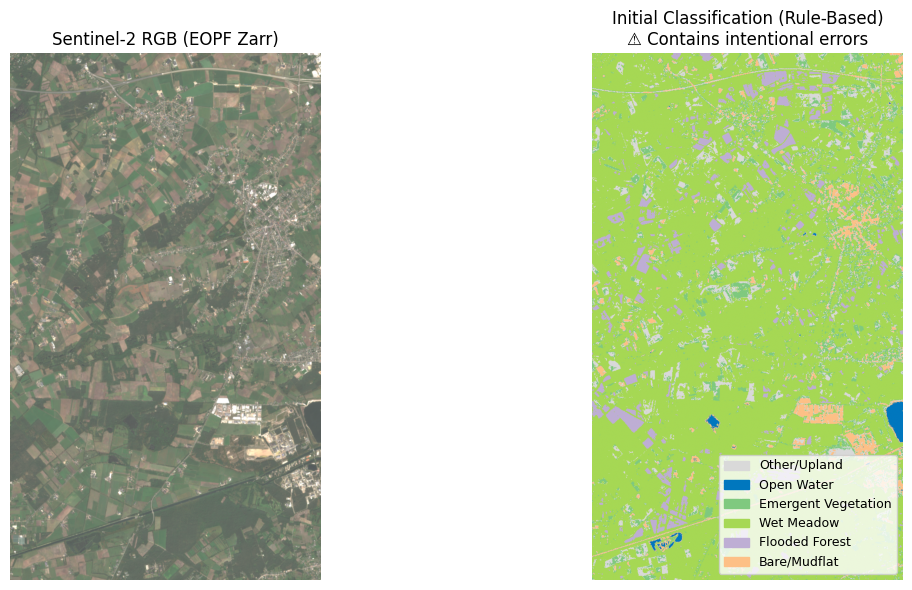

In [12]:
# Visualize initial classification
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# RGB
axes[0].imshow(rgb)
axes[0].set_title("Sentinel-2 RGB (EOPF Zarr)", fontsize=12)
axes[0].axis('off')

# Classification
colors = [WETLAND_CLASSES[i]["color"] for i in range(len(WETLAND_CLASSES))]
cmap = ListedColormap(colors)

im = axes[1].imshow(initial_labels, cmap=cmap, vmin=0, vmax=len(WETLAND_CLASSES)-1)
axes[1].set_title("Initial Classification (Rule-Based)\n⚠️ Contains intentional errors", fontsize=12)
axes[1].axis('off')

# Legend
patches = [mpatches.Patch(color=WETLAND_CLASSES[i]["color"], label=WETLAND_CLASSES[i]["name"]) 
           for i in range(len(WETLAND_CLASSES))]
axes[1].legend(handles=patches, loc='lower right', fontsize=9)

plt.tight_layout()
plt.savefig("initial_classification.png", dpi=150, bbox_inches='tight')
plt.show()

## 🤖 Step 5: Train Initial ML Model (v1)

In [13]:
def prepare_features(indices):
    """
    Prepare feature matrix for ML classification.
    
    Features: spectral bands + indices
    """
    feature_names = ["blue", "green", "red", "nir", "ndvi", "ndwi", "ndmi_proxy", "wri"]
    
    features = []
    for name in feature_names:
        features.append(indices[name].ravel())
    
    X = np.column_stack(features)
    return X, feature_names

# Prepare data
X, feature_names = prepare_features(indices)
y = initial_labels.ravel()

print(f"📊 Feature matrix: {X.shape}")
print(f"📊 Features: {feature_names}")

# Handle NaN values
valid_mask = ~np.isnan(X).any(axis=1)
X_valid = X[valid_mask]
y_valid = y[valid_mask]

print(f"✅ Valid samples: {valid_mask.sum():,} / {len(valid_mask):,}")

📊 Feature matrix: (754377, 8)
📊 Features: ['blue', 'green', 'red', 'nir', 'ndvi', 'ndwi', 'ndmi_proxy', 'wri']
✅ Valid samples: 754,377 / 754,377


In [14]:
# Sample for training
np.random.seed(42)
sample_size = min(30000, len(y_valid))
sample_idx = np.random.choice(len(y_valid), sample_size, replace=False)

X_sample = X_valid[sample_idx]
y_sample = y_valid[sample_idx]

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X_sample, y_sample, test_size=0.2, random_state=42, stratify=y_sample
)

print(f"📊 Training samples: {len(X_train):,}")
print(f"📊 Test samples: {len(X_test):,}")

📊 Training samples: 24,000
📊 Test samples: 6,000


In [15]:
# Train Model v1
print("🌲 Training Random Forest Model v1...")

model_v1 = RandomForestClassifier(
    n_estimators=100,
    max_depth=12,
    min_samples_split=10,
    min_samples_leaf=5,
    n_jobs=-1,
    random_state=42,
    class_weight='balanced'
)

model_v1.fit(X_train, y_train)
print("✅ Model v1 trained!")

# Evaluate
y_pred_v1 = model_v1.predict(X_test)
accuracy_v1 = accuracy_score(y_test, y_pred_v1)

print(f"\n📈 Model v1 Test Accuracy: {accuracy_v1:.2%}")
print("\n📋 Classification Report (v1):")
print(classification_report(
    y_test, y_pred_v1,
    target_names=[WETLAND_CLASSES[i]["name"] for i in range(len(WETLAND_CLASSES))],
    zero_division=0
))

🌲 Training Random Forest Model v1...
✅ Model v1 trained!

📈 Model v1 Test Accuracy: 99.90%

📋 Classification Report (v1):
                     precision    recall  f1-score   support

       Other/Upland       1.00      1.00      1.00       448
         Open Water       0.96      0.93      0.95        28
Emergent Vegetation       1.00      1.00      1.00       474
         Wet Meadow       1.00      1.00      1.00      4560
     Flooded Forest       1.00      1.00      1.00       300
       Bare/Mudflat       0.98      0.99      0.99       190

           accuracy                           1.00      6000
          macro avg       0.99      0.99      0.99      6000
       weighted avg       1.00      1.00      1.00      6000



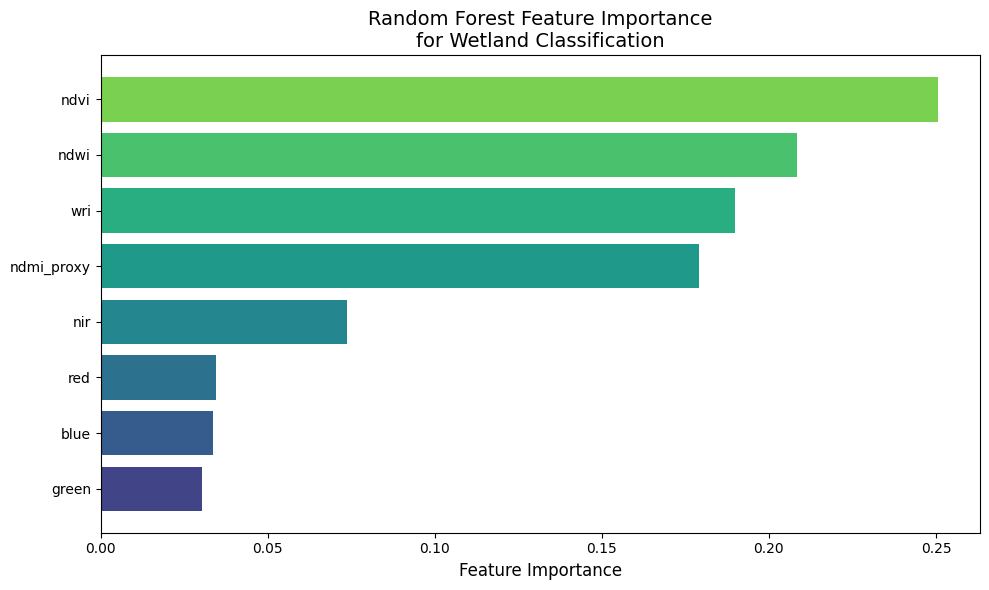

In [16]:
# Feature importance
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': model_v1.feature_importances_
}).sort_values('Importance', ascending=True)

plt.figure(figsize=(10, 6))
colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(importance_df)))
plt.barh(importance_df['Feature'], importance_df['Importance'], color=colors)
plt.xlabel('Feature Importance', fontsize=12)
plt.title('Random Forest Feature Importance\nfor Wetland Classification', fontsize=14)
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=150, bbox_inches='tight')
plt.show()

## 🗺️ Step 6: Generate Prediction Map

In [17]:
# Generate full prediction
print("🔮 Generating prediction map v1...")

prediction_flat = np.zeros(len(y), dtype=np.uint8)
prediction_flat[valid_mask] = model_v1.predict(X_valid)
prediction_v1 = prediction_flat.reshape(initial_labels.shape)

print("✅ Prediction map generated!")

🔮 Generating prediction map v1...
✅ Prediction map generated!


In [18]:
# Save outputs as Cloud Optimized GeoTIFF (COG)
output_dir = "wetland_outputs"
os.makedirs(output_dir, exist_ok=True)

# Create geotransform
transform = from_bounds(
    west_utm, south_utm, east_utm, north_utm,
    prediction_v1.shape[1], prediction_v1.shape[0]
)

# Handle CRS - use proj4 string to avoid PROJ database version issues
# UTM Zone 31N (EPSG:32631)
crs_proj4 = "+proj=utm +zone=31 +datum=WGS84 +units=m +no_defs"

try:
    from rasterio.crs import CRS
    output_crs = CRS.from_proj4(crs_proj4)
except Exception as e:
    print(f"⚠️ CRS from proj4 failed: {e}, trying WKT...")
    try:
        wkt = 'PROJCS["WGS 84 / UTM zone 31N",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",3],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1]]'
        output_crs = CRS.from_wkt(wkt)
    except:
        output_crs = None
        print("⚠️ Could not set CRS - files will be saved without georeferencing")

# Save prediction as COG
prediction_v1_path = f"{output_dir}/wetland_prediction_v1.tif"
rasterio_kwargs = {
    'driver': 'COG',  # Cloud Optimized GeoTIFF
    'height': prediction_v1.shape[0],
    'width': prediction_v1.shape[1],
    'count': 1,
    'dtype': np.uint8,
    'transform': transform,
    'compress': 'LZW',  # COG compression
}
if output_crs:
    rasterio_kwargs['crs'] = output_crs

with rasterio.open(prediction_v1_path, 'w', **rasterio_kwargs) as dst:
    dst.write(prediction_v1, 1)
print(f"✅ Saved COG: {prediction_v1_path}")

# Save RGB as COG
rgb_path = f"{output_dir}/sentinel2_rgb.tif"
rgb_uint8 = (np.clip(rgb, 0, 1) * 255).astype(np.uint8)
rasterio_kwargs_rgb = {
    'driver': 'COG',  # Cloud Optimized GeoTIFF
    'height': rgb_uint8.shape[0],
    'width': rgb_uint8.shape[1],
    'count': 3,
    'dtype': np.uint8,
    'transform': transform,
    'compress': 'LZW',  # COG compression
}
if output_crs:
    rasterio_kwargs_rgb['crs'] = output_crs

with rasterio.open(rgb_path, 'w', **rasterio_kwargs_rgb) as dst:
    for i in range(3):
        dst.write(rgb_uint8[:, :, i], i + 1)
print(f"✅ Saved COG: {rgb_path}")

✅ Saved COG: wetland_outputs/wetland_prediction_v1.tif
✅ Saved COG: wetland_outputs/sentinel2_rgb.tif


## ✏️ Step 7: JupyterGIS Annotation Workflow

Create a `.jGIS` document for collaborative annotation.

In [19]:
# Create JupyterGIS document
JGIS_FILE = "Wetland_Annotation.jGIS"

# GitHub raw URLs for the data
GITHUB_BASE = "https://raw.githubusercontent.com/annefou/jupytergis-showcases/refs/heads/main/content/wetland_outputs"

# Calculate center coordinates for the map
center_lat = (STUDY_AREA["spatial_extent"]["north"] + STUDY_AREA["spatial_extent"]["south"]) / 2
center_lon = (STUDY_AREA["spatial_extent"]["east"] + STUDY_AREA["spatial_extent"]["west"]) / 2

if JUPYTERGIS_AVAILABLE:
    if os.path.exists(JGIS_FILE):
        os.remove(JGIS_FILE)
    
    doc = GISDocument(
        JGIS_FILE,
        latitude=center_lat,
        longitude=center_lon,
        zoom=13
    )
    
    # Add basemap
    doc.add_raster_layer(
        url="https://tile.openstreetmap.org/{z}/{x}/{y}.png",
        name="OpenStreetMap"
    )

    # Add satellite basemap for reference
    doc.add_raster_layer(
        url="https://server.arcgisonline.com/ArcGIS/rest/services/World_Imagery/MapServer/tile/{z}/{y}/{x}",
        name="Satellite (ESRI)"
    )

    print("URL = " + f"{GITHUB_BASE}/{os.path.basename(rgb_path)}")
    # Add RGB layer - use file:// protocol for local files
    doc.add_tiff_layer(
        url=f"{GITHUB_BASE}/{os.path.basename(rgb_path)}",
        min=0,
        max=255,
        name="Sentinel-2 RGB (EOPF)"
    )

    wetland_colors = doc.create_color_expr(
        interpolation_type="linear",
        band=1,
        color_stops={
            0.0: [0, 100, 255, 1.0],       # Blue - Open Water
            1.0: [194, 178, 128, 1.0],     # Tan - Bare/Mudflat
            2.0: [144, 238, 144, 1.0],     # Light Green - Emergent Vegetation
            3.0: [128, 128, 128, 1.0],     # Gray - Other (Non-wetland)
            4.0: [173, 255, 47, 1.0],      # Yellow-Green - Wet Meadow
            5.0: [0, 100, 0, 1.0],         # Dark Green - Flooded Forest
        },
    )
     
    print("URl = " + f"{GITHUB_BASE}/{os.path.basename(prediction_v1_path)}")
    # Add prediction layer
    doc.add_tiff_layer(
        url=f"{GITHUB_BASE}/{os.path.basename(prediction_v1_path)}",
        name="Wetland Classification v1",
        color_expr=wetland_colors,
        normalize=False,  # Important! Keep raw class values (0-5), don't normalize to 0-1
    )
    
    print(f"✅ Created JupyterGIS document: {JGIS_FILE}")
    print("\n" + "="*60)
    print("📝 ANNOTATION WORKFLOW")
    print("="*60)
    print("""
    1. Open the .jGIS file from the file browser (double-click)
    2. Compare prediction with RGB imagery
    3. Right-click on misclassified areas → 'Add Annotation'
    4. Enter the correct class:
       - open_water
       - emergent_vegetation  
       - wet_meadow
       - flooded_forest
       - bare_mudflat
       - other
    5. Save (Ctrl+S)
    6. Return here to extract corrections
    """)
else:
    print("⚠️ JupyterGIS not available - skipping document creation")


URL = https://raw.githubusercontent.com/annefou/jupytergis-showcases/refs/heads/main/content/wetland_outputs/sentinel2_rgb.tif
URl = https://raw.githubusercontent.com/annefou/jupytergis-showcases/refs/heads/main/content/wetland_outputs/wetland_prediction_v1.tif
✅ Created JupyterGIS document: Wetland_Annotation.jGIS

📝 ANNOTATION WORKFLOW

    1. Open the .jGIS file from the file browser (double-click)
    2. Compare prediction with RGB imagery
    3. Right-click on misclassified areas → 'Add Annotation'
    4. Enter the correct class:
       - open_water
       - emergent_vegetation  
       - wet_meadow
       - flooded_forest
       - bare_mudflat
       - other
    5. Save (Ctrl+S)
    6. Return here to extract corrections
    


In [20]:
# Display map widget
if JUPYTERGIS_AVAILABLE:
    display(doc)

### 📝 Inject Pre-made Annotations

For the demo, we pre-populate the map with **expert annotations** from a GeoJSON file.
During the live demo, you can add more annotations manually to show the workflow.

In [21]:
# Load and inject pre-made annotations into jGIS
import math
import uuid

def wgs84_to_webmercator(lon, lat):
    """Convert WGS84 (lon, lat) to Web Mercator (x, y)."""
    x = lon * 20037508.34 / 180
    y = math.log(math.tan((90 + lat) * math.pi / 360)) / (math.pi / 180)
    y = y * 20037508.34 / 180
    return x, y

def inject_annotations_from_geojson(geojson_path, jgis_path):
    """Load GeoJSON annotations and inject into .jGIS file with correct format."""
    
    with open(geojson_path, 'r') as f:
        geojson = json.load(f)
    
    with open(jgis_path, 'r') as f:
        jgis_doc = json.load(f)
    
    if 'metadata' not in jgis_doc:
        jgis_doc['metadata'] = {}
    
    count = 0
    for feature in geojson['features']:
        ann_id = f"annotation_{uuid.uuid4()}"
        lon, lat = feature['geometry']['coordinates']
        x, y = wgs84_to_webmercator(lon, lat)
        
        props = feature['properties']
        
        # Use the correct JupyterGIS annotation format
        jgis_doc['metadata'][ann_id] = {
            "contents": [
                {
                    "user": {
                        "avatar_url": None,
                        "color": "var(--jp-collaborator-color3)",
                        "display_name": "Expert Reviewer",
                        "initials": "ER",
                        "name": "Expert Reviewer",
                        "username": "expert_review"
                    },
                    "value": props.get('class', 'unknown')
                }
            ],
            "label": props.get('comment', 'Correction'),
            "open": True,
            "parent": "",
            "position": {
                "x": x,
                "y": y
            },
            "zoom": 17.0
        }
        count += 1
    
    with open(jgis_path, 'w') as f:
        json.dump(jgis_doc, f, indent=2)
    
    return count

# Create demo_annotations.geojson if it doesn't exist
demo_annotations = {
    "type": "FeatureCollection",
    "features": [
        {
            "type": "Feature",
            "geometry": {"type": "Point", "coordinates": [5.044, 51.253]},
            "properties": {"class": "open_water", "comment": "Misclassified pond"}
        },
        {
            "type": "Feature",
            "geometry": {"type": "Point", "coordinates": [5.042, 51.251]},
            "properties": {"class": "wet_meadow", "comment": "Seasonal flooding"}
        }
    ]
}

with open('demo_annotations.geojson', 'w') as f:
    json.dump(demo_annotations, f)

# Inject annotations
if os.path.exists(JGIS_FILE):
    n_injected = inject_annotations_from_geojson('demo_annotations.geojson', JGIS_FILE)
    print(f"✅ Injected {n_injected} annotations into {JGIS_FILE}")

✅ Injected 2 annotations into Wetland_Annotation.jGIS


In [22]:
# Display map widget
if JUPYTERGIS_AVAILABLE:
    display(doc)

## 🔄 Step 8: Simulate Expert Corrections

For demo purposes, simulate corrections that would normally come from annotation.

In [23]:
# Extract annotations from jGIS file
def webmercator_to_wgs84(x, y):
    """Convert Web Mercator (x, y) to WGS84 (lon, lat)."""
    lon = x * 180 / 20037508.34
    lat = math.atan(math.exp(y * math.pi / 20037508.34)) * 360 / math.pi - 90
    return lon, lat

def extract_annotations_from_jgis(jgis_path):
    """Extract all annotations from the .jGIS file."""
    with open(jgis_path, 'r') as f:
        jgis_doc = json.load(f)
    
    annotations = []
    metadata = jgis_doc.get('metadata', {})
    
    for key, value in metadata.items():
        if key.startswith('annotation_'):
            if isinstance(value, dict) and 'position' in value:  # Changed from 'coordinates'
                pos = value['position']
                x, y = pos['x'], pos['y']
                lon, lat = webmercator_to_wgs84(x, y)
                
                # Get the class label from contents
                label = 'unknown'
                contents = value.get('contents', [])
                if contents and len(contents) > 0:
                    label = contents[0].get('value', 'unknown')
                
                annotations.append({
                    'id': key,
                    'lon': lon,
                    'lat': lat,
                    'x_webmercator': x,
                    'y_webmercator': y,
                    'label': label,
                    'description': value.get('label', ''),
                })
    
    return annotations

def annotations_to_corrections(annotations, indices, transform, target_crs, window_size=5):
    """
    Convert jGIS annotations to pixel corrections for retraining.
    Expands each annotation to a window_size x window_size region.
    """
    from pyproj import Transformer as ProjTransformer
    
    label_to_class = {
        'other': 0,
        'open_water': 1,
        'emergent_vegetation': 2,
        'wet_meadow': 3,
        'flooded_forest': 4,
        'bare_mudflat': 5,
    }
    
    try:
        proj_transformer = ProjTransformer.from_crs("EPSG:4326", f"EPSG:{target_crs}", always_xy=True)
    except:
        proj_transformer = None
    
    corrections = []
    height, width = indices['ndvi'].shape
    half = window_size // 2
    
    for ann in annotations:
        label = ann['label'].lower().replace(' ', '_')
        if label not in label_to_class:
            print(f"  ⚠️ Unknown label '{label}', skipping")
            continue
        
        new_class = label_to_class[label]
        
        if proj_transformer:
            utm_x, utm_y = proj_transformer.transform(ann['lon'], ann['lat'])
        else:
            utm_x = (ann['lon'] - 3) * 111320 * math.cos(math.radians(ann['lat'])) + 500000
            utm_y = ann['lat'] * 110540
        
        col = int((utm_x - transform.c) / transform.a)
        row = int((utm_y - transform.f) / transform.e)
        
        # Expand to window around annotation point
        for dr in range(-half, half + 1):
            for dc in range(-half, half + 1):
                r, c = row + dr, col + dc
                if 0 <= r < height and 0 <= c < width:
                    old_class = prediction_v1[r, c]
                    if old_class != new_class:
                        corrections.append({
                            'row': r,
                            'col': c,
                            'old_class': old_class,
                            'new_class': new_class,
                            'class_name': ann['label'],
                            'description': ann['description']
                        })
    
    return corrections

# Extract annotations from jGIS
print("📝 Extracting annotations from jGIS file...")
if os.path.exists(JGIS_FILE):
    jgis_annotations = extract_annotations_from_jgis(JGIS_FILE)
    print(f"✅ Found {len(jgis_annotations)} annotations in {JGIS_FILE}")
    
    if jgis_annotations:
        print("\n📊 Annotation Summary:")
        label_counts = {}
        for ann in jgis_annotations:
            label = ann['label']
            label_counts[label] = label_counts.get(label, 0) + 1
        
        for label, count in sorted(label_counts.items()):
            print(f"   {label}: {count}")
        
        # Convert to corrections
        print("\n🔄 Converting annotations to pixel corrections...")
        corrections = annotations_to_corrections(
            jgis_annotations, indices, transform, target_crs
        )
        print(f"✅ Generated {len(corrections)} corrections from annotations")
        
        if corrections:
            print("\n📊 Correction Summary:")
            for c in corrections[:5]:  # Show first 5
                old_name = WETLAND_CLASSES[c['old_class']]['name']
                new_name = WETLAND_CLASSES[c['new_class']]['name']
                print(f"   {old_name} → {new_name}: {c['description'][:40]}...")
            if len(corrections) > 5:
                print(f"   ... and {len(corrections) - 5} more")
    else:
        print("⚠️ No annotations found - using simulated corrections for demo")
        corrections = []
else:
    print(f"⚠️ {JGIS_FILE} not found - using simulated corrections for demo")
    corrections = []

# Fallback: simulate corrections if none from jGIS
if not corrections:
    print("\n🔄 Generating simulated corrections for demo...")
    np.random.seed(123)
    
    ndvi = indices['ndvi']
    ndwi = indices['ndwi']
    valid = ~np.isnan(ndvi)
    
    # Find likely misclassifications
    for target_class, mask_condition, class_name in [
        (1, valid & (ndwi > 0.2) & (prediction_v1 != 1), "Open Water"),
        (2, valid & (ndvi > 0.25) & (ndvi < 0.45) & (ndwi > -0.2) & (prediction_v1 != 2), "Emergent Vegetation"),
        (4, valid & (ndvi > 0.55) & (prediction_v1 != 4), "Flooded Forest"),
    ]:
        error_idx = np.where(mask_condition)
        if len(error_idx[0]) > 0:
            n_sample = min(100, len(error_idx[0]))
            idx = np.random.choice(len(error_idx[0]), n_sample, replace=False)
            for i in idx:
                corrections.append({
                    'row': error_idx[0][i],
                    'col': error_idx[1][i],
                    'old_class': prediction_v1[error_idx[0][i], error_idx[1][i]],
                    'new_class': target_class,
                    'class_name': class_name
                })
    
    print(f"✅ Generated {len(corrections)} simulated corrections")


📝 Extracting annotations from jGIS file...
✅ Found 2 annotations in Wetland_Annotation.jGIS

📊 Annotation Summary:
   open_water: 1
   wet_meadow: 1

🔄 Converting annotations to pixel corrections...
✅ Generated 39 corrections from annotations

📊 Correction Summary:
   Other/Upland → Open Water: Misclassified pond...
   Other/Upland → Open Water: Misclassified pond...
   Other/Upland → Open Water: Misclassified pond...
   Other/Upland → Open Water: Misclassified pond...
   Other/Upland → Open Water: Misclassified pond...
   ... and 34 more


## 🔄 Step 9: Retrain Model with Corrections (v2)

In [24]:
# Apply corrections
corrected_labels = initial_labels.copy()

for c in corrections:
    corrected_labels[c['row'], c['col']] = c['new_class']

print(f"✅ Applied {len(corrections)} corrections")

# Prepare corrected training data
y_corrected = corrected_labels.ravel()
y_corrected_valid = y_corrected[valid_mask]

# Sample
np.random.seed(42)
sample_idx_v2 = np.random.choice(len(y_corrected_valid), sample_size, replace=False)
X_sample_v2 = X_valid[sample_idx_v2]
y_sample_v2 = y_corrected_valid[sample_idx_v2]

# Split
X_train_v2, X_test_v2, y_train_v2, y_test_v2 = train_test_split(
    X_sample_v2, y_sample_v2, test_size=0.2, random_state=42, stratify=y_sample_v2
)

✅ Applied 39 corrections


In [25]:
# Train Model v2
print("🌲 Training Random Forest Model v2 (with corrections)...")

model_v2 = RandomForestClassifier(
    n_estimators=100,
    max_depth=12,
    min_samples_split=10,
    min_samples_leaf=5,
    n_jobs=-1,
    random_state=42,
    class_weight='balanced'
)

model_v2.fit(X_train_v2, y_train_v2)
print("✅ Model v2 trained!")

# Evaluate
y_pred_v2 = model_v2.predict(X_test_v2)
accuracy_v2 = accuracy_score(y_test_v2, y_pred_v2)

print(f"\n📈 Model v2 Test Accuracy: {accuracy_v2:.2%}")
print("\n📋 Classification Report (v2):")
print(classification_report(
    y_test_v2, y_pred_v2,
    target_names=[WETLAND_CLASSES[i]["name"] for i in range(len(WETLAND_CLASSES))],
    zero_division=0
))

🌲 Training Random Forest Model v2 (with corrections)...
✅ Model v2 trained!

📈 Model v2 Test Accuracy: 99.92%

📋 Classification Report (v2):
                     precision    recall  f1-score   support

       Other/Upland       1.00      1.00      1.00       448
         Open Water       0.96      0.93      0.95        28
Emergent Vegetation       1.00      1.00      1.00       474
         Wet Meadow       1.00      1.00      1.00      4560
     Flooded Forest       1.00      1.00      1.00       300
       Bare/Mudflat       0.99      0.99      0.99       190

           accuracy                           1.00      6000
          macro avg       0.99      0.99      0.99      6000
       weighted avg       1.00      1.00      1.00      6000



In [26]:
# Generate prediction v2
print("🔮 Generating prediction map v2...")

prediction_flat_v2 = np.zeros(len(y), dtype=np.uint8)
prediction_flat_v2[valid_mask] = model_v2.predict(X_valid)
prediction_v2 = prediction_flat_v2.reshape(initial_labels.shape)

print("✅ Prediction v2 generated!")

🔮 Generating prediction map v2...
✅ Prediction v2 generated!


## 📊 Step 10: Compare Results

Pixels changed: 218 (0.03%)


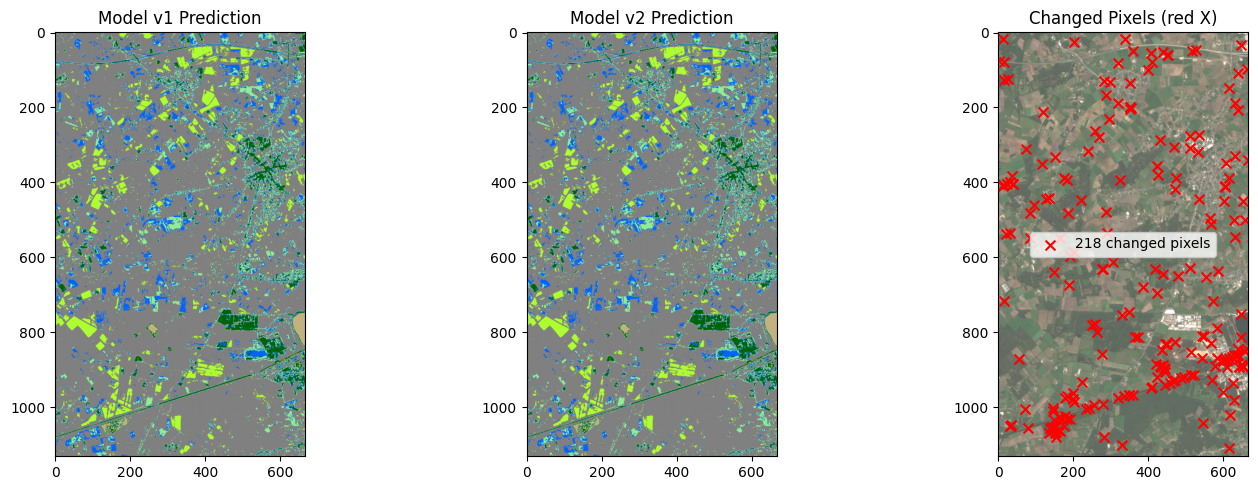

In [28]:
from matplotlib.colors import ListedColormap

# Compare predictions
diff_map = prediction_v1 != prediction_v2

print(f"Pixels changed: {diff_map.sum()} ({100*diff_map.mean():.2f}%)")

# Define wetland colormap matching JupyterGIS colors
wetland_colors_mpl = [
    [0/255, 100/255, 255/255, 1.0],       # 0: Blue - Open Water
    [194/255, 178/255, 128/255, 1.0],     # 1: Tan - Bare/Mudflat
    [144/255, 238/255, 144/255, 1.0],     # 2: Light Green - Emergent Vegetation
    [128/255, 128/255, 128/255, 1.0],     # 3: Gray - Other
    [173/255, 255/255, 47/255, 1.0],      # 4: Yellow-Green - Wet Meadow
    [0/255, 100/255, 0/255, 1.0],         # 5: Dark Green - Flooded Forest
]
wetland_cmap = ListedColormap(wetland_colors_mpl)

# Find locations of changed pixels
changed_y, changed_x = np.where(diff_map)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# V1 prediction
axes[0].imshow(prediction_v1, cmap=wetland_cmap, vmin=0, vmax=5)
axes[0].set_title("Model v1 Prediction")

# V2 prediction  
axes[1].imshow(prediction_v2, cmap=wetland_cmap, vmin=0, vmax=5)
axes[1].set_title("Model v2 Prediction")

# Difference map with highlighted points
axes[2].imshow(rgb)
if len(changed_x) > 0:
    axes[2].scatter(changed_x, changed_y, c='red', s=50, marker='x', label=f'{len(changed_x)} changed pixels')
    axes[2].legend()
axes[2].set_title("Changed Pixels (red X)")

plt.tight_layout()
plt.show()

In [29]:
# Summary
print("\n" + "="*65)
print("📊 MODEL IMPROVEMENT SUMMARY")
print("="*65)
print(f"\n🔹 Model v1 (Initial labels):      {accuracy_v1:.2%} accuracy")
print(f"🔹 Model v2 (Corrected labels):    {accuracy_v2:.2%} accuracy")
print(f"\n📈 Improvement: {(accuracy_v2 - accuracy_v1)*100:+.2f} percentage points")
print(f"📝 Corrections applied: {len(corrections)}")
print(f"🗺️ Pixels changed in prediction: {diff_map.sum():,} ({100*diff_map.mean():.2f}%)")
print("\n" + "="*65)


📊 MODEL IMPROVEMENT SUMMARY

🔹 Model v1 (Initial labels):      99.90% accuracy
🔹 Model v2 (Corrected labels):    99.92% accuracy

📈 Improvement: +0.02 percentage points
📝 Corrections applied: 39
🗺️ Pixels changed in prediction: 218 (0.03%)



## 💾 Step 11: Export Final Results

In [30]:
# Save final prediction
prediction_v2_path = f"{output_dir}/wetland_prediction_v2_corrected.tif"
rasterio_kwargs = {
    'driver': 'GTiff',
    'height': prediction_v2.shape[0],
    'width': prediction_v2.shape[1],
    'count': 1,
    'dtype': np.uint8,
    'transform': transform,
}
if output_crs:
    rasterio_kwargs['crs'] = output_crs

with rasterio.open(prediction_v2_path, 'w', **rasterio_kwargs) as dst:
    dst.write(prediction_v2, 1)
print(f"✅ Saved: {prediction_v2_path}")

# Save models
joblib.dump(model_v1, f"{output_dir}/wetland_model_v1.joblib")
joblib.dump(model_v2, f"{output_dir}/wetland_model_v2.joblib")
print(f"✅ Saved models to {output_dir}/")

# Export corrections as GeoJSON
def corrections_to_geojson(corrections, transform, crs):
    features = []
    for i, c in enumerate(corrections):
        x, y = rasterio.transform.xy(transform, c['row'], c['col'])
        features.append({
            "type": "Feature",
            "geometry": {"type": "Point", "coordinates": [x, y]},
            "properties": {
                "id": i,
                "old_class": int(c['old_class']),
                "old_class_name": WETLAND_CLASSES[c['old_class']]['name'],
                "new_class": int(c['new_class']),
                "new_class_name": WETLAND_CLASSES[c['new_class']]['name']
            }
        })
    return {"type": "FeatureCollection", "features": features}

geojson = corrections_to_geojson(corrections, transform, target_crs)
with open(f"{output_dir}/corrections.geojson", 'w') as f:
    json.dump(geojson, f, indent=2)
print(f"✅ Saved: {output_dir}/corrections.geojson")

# List outputs
print("\n📁 Output Files:")
for f in sorted(os.listdir(output_dir)):
    size = os.path.getsize(f"{output_dir}/{f}") / 1024
    print(f"   📄 {f} ({size:.1f} KB)")

✅ Saved: wetland_outputs/wetland_prediction_v2_corrected.tif
✅ Saved models to wetland_outputs/
✅ Saved: wetland_outputs/corrections.geojson

📁 Output Files:
   📄 .ipynb_checkpoints (0.2 KB)
   📄 comparison_v1_v2.png (2112.7 KB)
   📄 corrections.geojson (13.8 KB)
   📄 sentinel2_rgb.tif (2671.7 KB)
   📄 wetland_model_v1.joblib (1714.0 KB)
   📄 wetland_model_v2.joblib (1847.9 KB)
   📄 wetland_prediction_v1.tif (118.6 KB)
   📄 wetland_prediction_v2_corrected.tif (737.6 KB)


## 🎯 Summary & Conclusions

### What We Demonstrated

| Step | Description | Tools |
|------|-------------|-------|
| 1. Data Access | **EOPF Sample Service** S3 storage | `s3fs`, `xarray` |
| 2. Data Loading | EOPF Zarr format with multi-temporal | `xr.open_mfdataset` |
| 3. Cloud Masking | SCL layer from EOPF product | EOPF structure |
| 4. Feature Engineering | Spectral indices (NDVI, NDWI) | `numpy` |
| 5. ML Training v1 | Random Forest classifier | `scikit-learn` |
| 6. Visualization | Interactive map | **JupyterGIS** |
| 7. Annotation | Expert corrections | **JupyterGIS annotations** |
| 8. Retraining v2 | Improved model | `scikit-learn` |
| 9. Export | GeoTIFF + GeoJSON | `rasterio` |

### Key Takeaways

1. **EOPF Zarr format** enables efficient cloud-native access to Sentinel data
2. **Human-in-the-loop ML** improves classification accuracy
3. **JupyterGIS** enables collaborative annotation on geospatial data
4. **Iterative refinement** is key for biodiversity mapping

### Relevance for LifeWatch & Climate Adaptation

🌿 **Wetland mapping** supports:
- Essential Biodiversity Variables (EBV) monitoring
- Carbon stock assessment (peatlands store 30% of soil carbon)
- Climate adaptation planning (natural flood mitigation)
- EU Nature Restoration Law compliance
- Ramsar Convention reporting

---

**EOPF + JupyterGIS + ML = Cloud-Native Biodiversity Monitoring** 🚀

## 📚 References

### Data Sources
- **EOPF Sample Service**: https://zarr.eopf.copernicus.eu/
- **EOPF STAC Catalog**: https://stac.core.eopf.eodc.eu
- **EOPF Sample Notebooks**: https://eopf-sample-service.github.io/eopf-sample-notebooks/

### Software
- **JupyterGIS**: https://github.com/geojupyter/jupytergis
- **EOPF Toolkit**: https://github.com/eopf-toolkit